In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from core.training import train_tise
from tise1d.tise1d import Loss_PDE, Loss_Orthogonality, PotentialHarmonicOscillator, ansatzfactor_HO_sym
from utils.utils import generate_input_data
from param_search.A_train_ground_state import load_ground_state_pinn
from tise1d.analytic_ho import compare_analytic

# Ground state test
We want to try 

In [2]:
device = "cpu"   # torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu" 

L = 5

# Parameters used throughout the project
x_lim = (-L, L)
N_samples = 256

# Generate data points
torch.manual_seed(124)
x = generate_input_data(N_samples, x_lim, device)
x_test = torch.linspace(x_lim[0], x_lim[1], N_samples).view(-1, 1).to(device)

# Load ground state PINN to use in orthogonality loss constraint
pinn1 = load_ground_state_pinn(device)

Predicted Energy: 0.500000, Exact Energy: 0.500000, Relative Error: 0.000000%


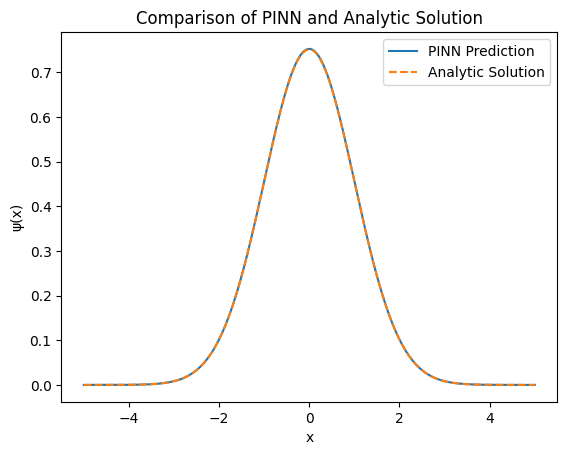

In [3]:
# Test pinn1
compare_analytic(x_test, x_lim, pinn1, 0)

As we can see, the model finds the exact ground state solution, even without tuning the hyperparameters. The energy converges to the correct value of $0.5$, and the wavefunction matches the exact solution very well. This makes sense, because the groun state solution is contained within the `ansatzfactor_HO_sym` used, however it is still impressive that the model is able to find the correct energy too.

This model for the ground state is now saved, and will be used to further train for excited states to ensure orthogonality to the ground state.

## First excited state, before grid search 

In this section, we train a neural network to find the first excited state of the quantum harmonic oscillator before any grid search. 

We choose some values for the hyperparameters that may be somewhat reasonable. We decide to choose a learning rate for the energy ($10^{-2}$) that is significantly larger than the ordinary learning rate ($10^{-4}$), since it is important that the energy is able to climb from a value of $0.5$ (the initial energy, equal to the ground state energy) to the first excited energy eigenvalue of $1.5$. Moreover, we choose a relatively large orthogonal loss weight of $10$, in order to make sure that the solution ends up being orthogonal to the ground state. 


In [4]:
pinn2 = train_tise(
    x,
    loss_func = Loss_PDE(PotentialHarmonicOscillator()) + 10*Loss_Orthogonality([pinn1]),
    x_lim=x_lim,
    lr = 1e-4,
    lr_energy=1e-2,
    E_init=0.5,
    width = 6,
    hidden_layers=2,
    ansatz_factor=ansatzfactor_HO_sym,
)

Epoch 100/3000. Best loss=9.952e+00. Current loss=9.952e+00. E=0.509069
Epoch 200/3000. Best loss=9.655e+00. Current loss=9.655e+00. E=0.550684
Epoch 300/3000. Best loss=8.387e+00. Current loss=8.387e+00. E=0.707324
Epoch 400/3000. Best loss=4.286e+00. Current loss=4.286e+00. E=1.159284
Epoch 500/3000. Best loss=6.193e-01. Current loss=6.193e-01. E=1.518346
Epoch 600/3000. Best loss=1.216e-01. Current loss=1.216e-01. E=1.563488
Epoch 700/3000. Best loss=9.625e-02. Current loss=9.625e-02. E=1.565262
Epoch 800/3000. Best loss=9.441e-02. Current loss=9.441e-02. E=1.565002
Epoch 900/3000. Best loss=9.324e-02. Current loss=9.324e-02. E=1.564683
Epoch 1000/3000. Best loss=9.201e-02. Current loss=9.201e-02. E=1.564339
Epoch 1100/3000. Best loss=9.072e-02. Current loss=9.072e-02. E=1.563967
Epoch 1200/3000. Best loss=8.937e-02. Current loss=8.937e-02. E=1.563565
Epoch 1300/3000. Best loss=8.797e-02. Current loss=8.797e-02. E=1.563133
Epoch 1400/3000. Best loss=8.652e-02. Current loss=8.652e-02

Predicted Energy: 1.550973, Exact Energy: 1.500000, Relative Error: 3.398204%


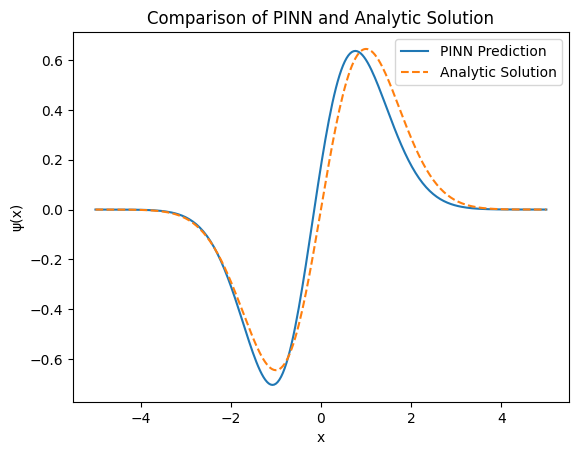

In [5]:
compare_analytic(x_test,x_lim,pinn2,n=1)

We see that the neural network is quite accurate, as it ends up with a solution with a very similar shape to the first excited energy level. However, it is nonehtless slightly off. The energy ends up being a percentage of 3.40 % off from the correct value. 